In [ ]:
import os
from google.colab import drive
if not os.path.ismount("/content/drive"):
    drive.mount("/content/drive", force_remount=False)
%cd "/content/drive/MyDrive/Capstone/rohlik-orders-forecasting-challenge"

/content/drive/MyDrive/Capstone/rohlik-orders-forecasting-challenge


In [ ]:
%%capture
%pip install skforecast
%pip install category_encoders
%pip install pmdarima

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from category_encoders import BinaryEncoder
from lightgbm import LGBMRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from skforecast.recursive import ForecasterRecursiveMultiSeries

In [ ]:
def calculate_wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

train_orders = pd.read_csv("train.csv")
train_calendar = pd.read_csv("train_calendar.csv")
print(f"train_orders.shape {train_orders.shape} train_calendar.shape {train_calendar.shape}")

common_cols = list(train_calendar.columns.intersection(train_orders.columns))
df = pd.merge(train_calendar, train_orders, on=common_cols, how="left")
df['orders'] = df['orders'].fillna(0)
df['date'] = pd.to_datetime(df['date'])
print(f"df.shape {df.shape}")

def add_time_features(df):
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    return df

df = add_time_features(df)

# Split (Last 60 days for validation)
split_date = df['date'].max() - timedelta(days=60)
df_train = df[df['date'] < split_date].copy()
df_test = df[df['date'] >= split_date].copy()
print(f"df_train.shape {df_train.shape} df_test.shape {df_test.shape}")

train_orders.shape (7340, 18) train_calendar.shape (13307, 15)
df.shape (13307, 19)
df_train.shape (12880, 23) df_test.shape (427, 23)


In [ ]:
num_features = ['precipitation', 'snow', 'day_sin', 'day_cos']
cat_features = ['holiday_name']
other_features =  ['holiday', 'shutdown', 'mini_shutdown','warehouse_limited', 'shops_closed', 'winter_school_holidays','school_holidays', 'blackout', 'mov_change', 'frankfurt_shutdown', 'day_of_week', 'month']
all_exog = num_features + cat_features + other_features

preprocessor = ColumnTransformer(
    transformers=[('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features + other_features),
        ('holiday_transform', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='No Holiday')),#('target_enc', TargetEncoder(categories='auto', target_type='continuous'))
            ('binary_enc', BinaryEncoder())]), cat_features)
    ]
)
# TODO: TargetEncoder, better encoding the holiday information

# Pivot for Skforecast
series_train = df_train.pivot(index='date', columns='warehouse', values='orders').asfreq('D')
series_test = df_test.pivot(index='date', columns='warehouse', values='orders').asfreq('D')

# Create Exog Dictionaries
exog_train_dict = {w: df_train[df_train['warehouse']==w].set_index('date')[all_exog].reindex(series_train.index).ffill().bfill() for w in series_train.columns}
exog_test_dict = {w: df_test[df_test['warehouse']==w].set_index('date')[all_exog].reindex(series_test.index).ffill().bfill() for w in series_test.columns}

In [ ]:
# TODO : Feature importance: SFS, permutation importance

# Model A: Ridge Regression (Skforecast)
forecaster_ridge = ForecasterRecursiveMultiSeries(
    estimator = Ridge(alpha=1.0), lags = 14,
    transformer_series = StandardScaler(), transformer_exog = preprocessor
)
forecaster_ridge.fit(series=series_train, exog=exog_train_dict)
preds_ridge = forecaster_ridge.predict(steps=len(series_test), exog=exog_test_dict).pivot(columns='level', values='pred')

# Model B: LightGBM (Skforecast)
forecaster_lgbm = ForecasterRecursiveMultiSeries(
    estimator = LGBMRegressor(n_estimators=100, random_state=42), lags = 14,
    transformer_series = StandardScaler(), transformer_exog = preprocessor
)
forecaster_lgbm.fit(series=series_train, exog=exog_train_dict)
preds_lgbm = forecaster_lgbm.predict(steps=len(series_test), exog=exog_test_dict).pivot(columns='level', values='pred')

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location : /usr/local/lib/python3.12/dist-packages/skforecast/utils/utils.py:2365    │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location : /usr/local/lib/python3.12/dist-packages/skforecast/utils/utils.py:2365    │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002422 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3977
[LightGBM] [Info] Number of data points in the train set: 12782, number of used features: 33
[LightGBM] [Info] Start training from score 0.008265


In [ ]:
forecaster_ridge.get_feature_importances()

,feature,importance
6,lag_7,0.454423
13,lag_14,0.299690
2,lag_3,0.110007
0,lag_1,0.108954
4,lag_5,0.063093
5,lag_6,0.052335
10,lag_11,0.041370
36,holiday_transform__0_5,0.029421
35,holiday_transform__0_4,0.025980
1,lag_2,0.025107


In [ ]:
forecaster_lgbm.get_feature_importances()

,feature,importance
0,lag_1,330
6,lag_7,243
13,lag_14,240
1,lag_2,212
2,lag_3,154
4,lag_5,144
5,lag_6,141
8,lag_9,137
7,lag_8,136
3,lag_4,116


In [ ]:
# Prophet
#sarima_preds_list = []
prophet_preds_list = []

for warehouse in series_train.columns:
    # SARIMA (1,1,1)x(0,1,1,7)
    #y_w = series_train[warehouse]
    #sarima_model = SARIMAX(y_w, order=(1,1,1), seasonal_order=(0,1,1,7)).fit(disp=False)
    #sarima_preds_list.append(sarima_model.forecast(steps=len(series_test)))

    # Prophet
    m = Prophet(weekly_seasonality=True, yearly_seasonality=True).fit(df_train[df_train['warehouse']==warehouse][['date', 'orders']].rename(columns={'date':'ds', 'orders':'y'}))
    p_forecast = m.predict(m.make_future_dataframe(periods=len(series_test)))
    prophet_preds_list.append(p_forecast.iloc[-len(series_test):]['yhat'].values)

#preds_sarima = pd.DataFrame(np.array(sarima_preds_list).T, index=series_test.index, columns=series_test.columns)
preds_prophet = pd.DataFrame(np.array(prophet_preds_list).T, index=series_test.index, columns=series_test.columns)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
def evaluate(actual, pred, name):
    mae = mean_absolute_error(actual, pred)
    wape = calculate_wape(actual.values, pred.values)
    r2 = r2_score(actual.values.flatten(), pred.values.flatten())
    return {'Model': name, 'MAE': round(mae, 2), 'WAPE (%)': round(wape*100, 2), 'R2': round(r2, 4)}

arima_list, sarima_list, sarimax_list, prophet_list = [], [], [], []

for warehouse in series_train.columns:
    y_train_w = series_train[warehouse]
    exog_train_w = exog_train_dict[warehouse]
    exog_test_w = exog_test_dict[warehouse]

    # A. Pure ARIMA (No seasonality, no exog)
    # p = 7 (Autoregressive - AR): The model looks back 7 days
    # d = 1 (Integrated - I): This is the Differencing ste
    # q = 1 (Moving Average - MA)
    m_arima = ARIMA(y_train_w, order=(7,1,1)).fit()
    arima_list.append(m_arima.forecast(steps=len(series_test)))

    # B. SARIMA (Seasonality, but no exog)

    # P=1: Seasonal AR. Looks at the same day last week
    # Non-Seasonal Part $(1, 1, 1)  p=1: Looks at yesterday.  d=1:Looks at the daily change.  q=1: Fixes yesterday's error.

    # Seasonal Part (1, 1, 1, 7) :
    # P=1: Seasonal AR. Looks at the same day last week   D=1:Seasonal Difference. Looks at the change between this Monday and last Monday.   Q=1: Seasonal MA. Fixes the error made in the forecast for the same day last week.  S=7: repeats every 7 days.
    m_sarima = SARIMAX(y_train_w, order=(1,1,1), seasonal_order=(1,1,1,7)).fit(disp=False)
    sarima_list.append(m_sarima.forecast(steps=len(series_test)))

    # C. SARIMAX (Seasonality + ALL External Features)
    # Note: We must encode exog for SARIMAX as it doesn't handle strings
    # Transforming exog for this warehouse specifically
    exog_train_transformed = preprocessor.fit_transform(exog_train_dict[warehouse])
    exog_test_transformed = preprocessor.transform(exog_test_dict[warehouse])

    m_sarimax = SARIMAX(y_train_w, exog=exog_train_transformed,
                        order=(1,1,1), seasonal_order=(1,1,1,7)).fit(disp=False)
    sarimax_list.append(m_sarimax.forecast(steps=len(series_test), exog=exog_test_transformed))


def list_to_df(lst):
    return pd.DataFrame(np.array(lst).T, index=series_test.index, columns=series_test.columns)

preds_arima = list_to_df(arima_list)
preds_sarima = list_to_df(sarima_list)
preds_sarimax = list_to_df(sarimax_list)

comparison = pd.DataFrame([
    evaluate(series_test, preds_ridge, "Ridge (ML)"),
    evaluate(series_test, preds_lgbm, "LightGBM (ML)"),
    evaluate(series_test, preds_arima, "ARIMA (Basic)"),
    evaluate(series_test, preds_sarima, "SARIMA (Seasonal)"),
    evaluate(series_test, preds_sarimax, "SARIMAX (Seasonal + Exog)"),
    evaluate(series_test, preds_prophet, "Prophet")
])

print("\n--- FINAL PERFORMANCE COMPARISON ---")
print(comparison)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/mod


--- FINAL PERFORMANCE COMPARISON ---
                       Model      MAE  WAPE (%)      R2
0                 Ridge (ML)   590.95      9.45  0.9045
1              LightGBM (ML)  1701.85     27.20  0.2653
2              ARIMA (Basic)   594.91      9.51  0.9044
3          SARIMA (Seasonal)   439.87      7.03  0.9444
4  SARIMAX (Seasonal + Exog)  1409.60     22.53  0.6025
5                    Prophet   607.18      9.71  0.8985


Prague_1


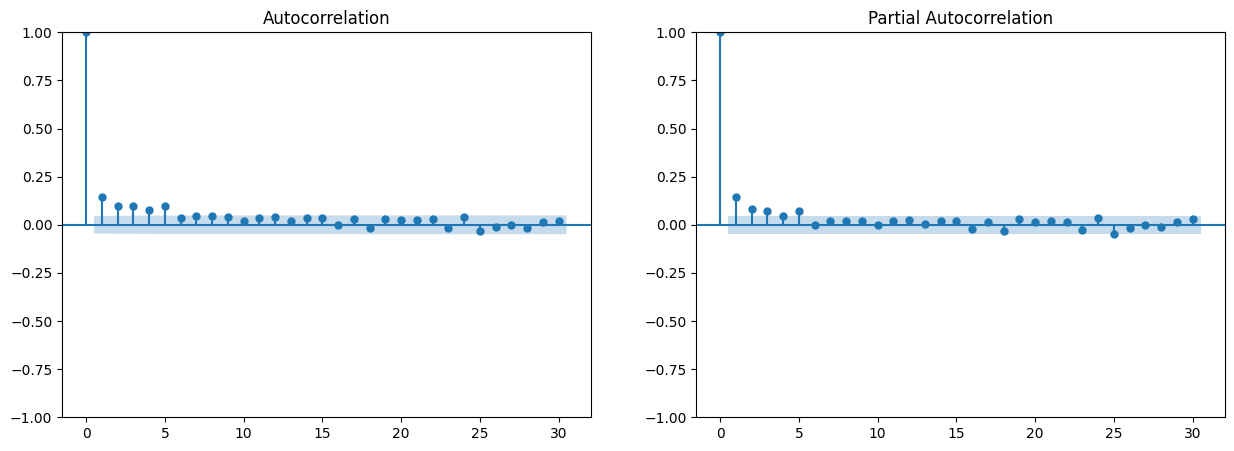

Brno_1


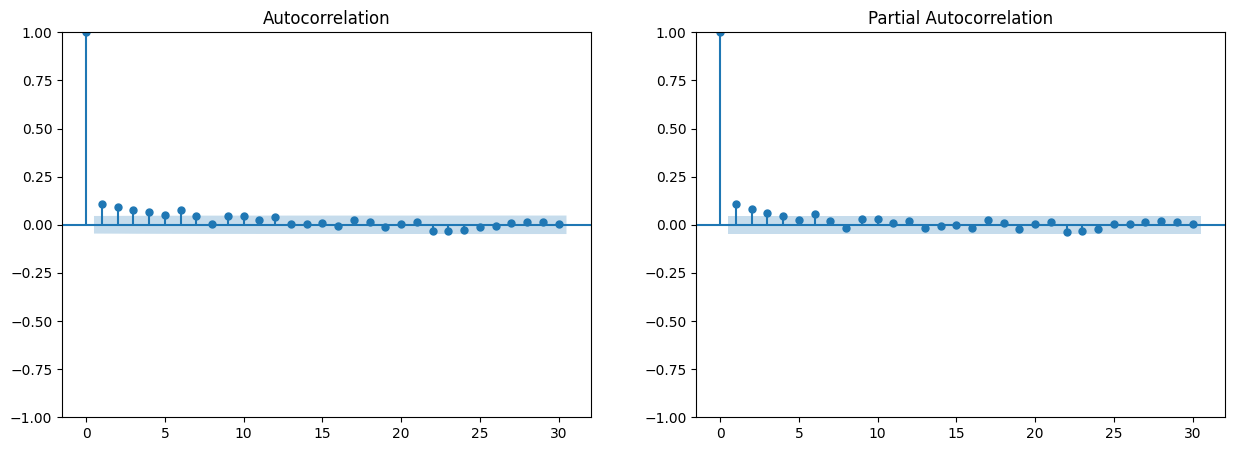

Prague_2


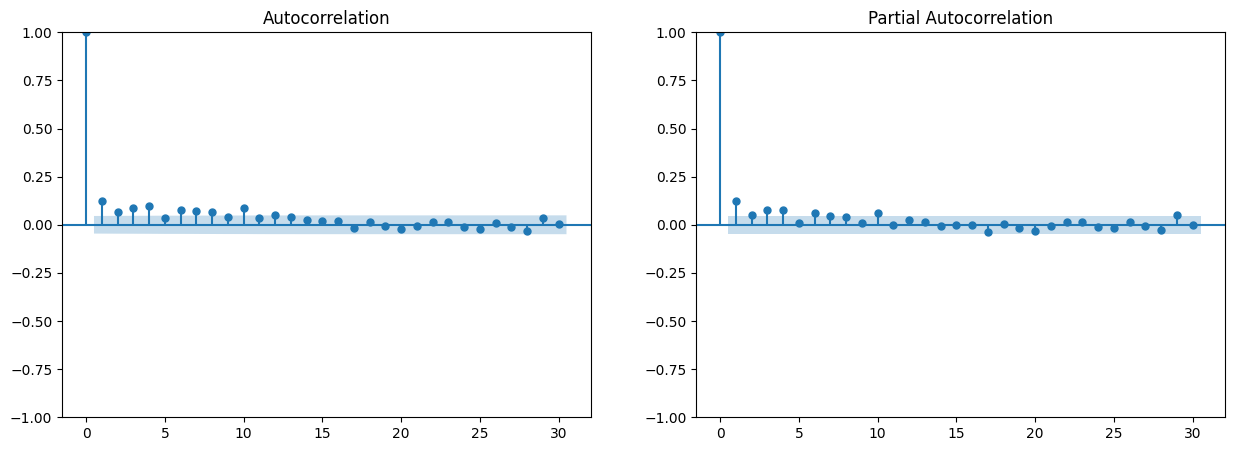

Prague_3


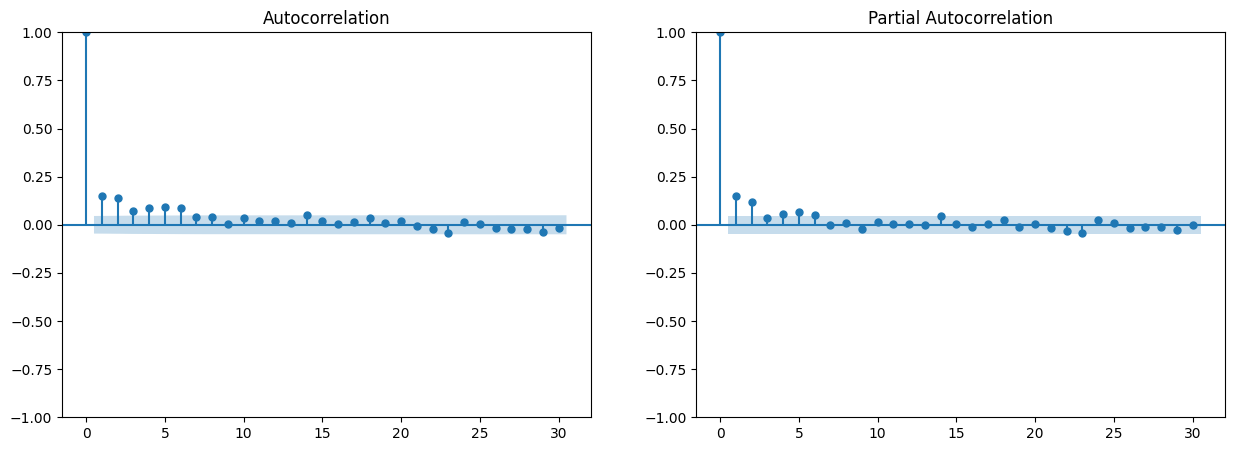

Munich_1


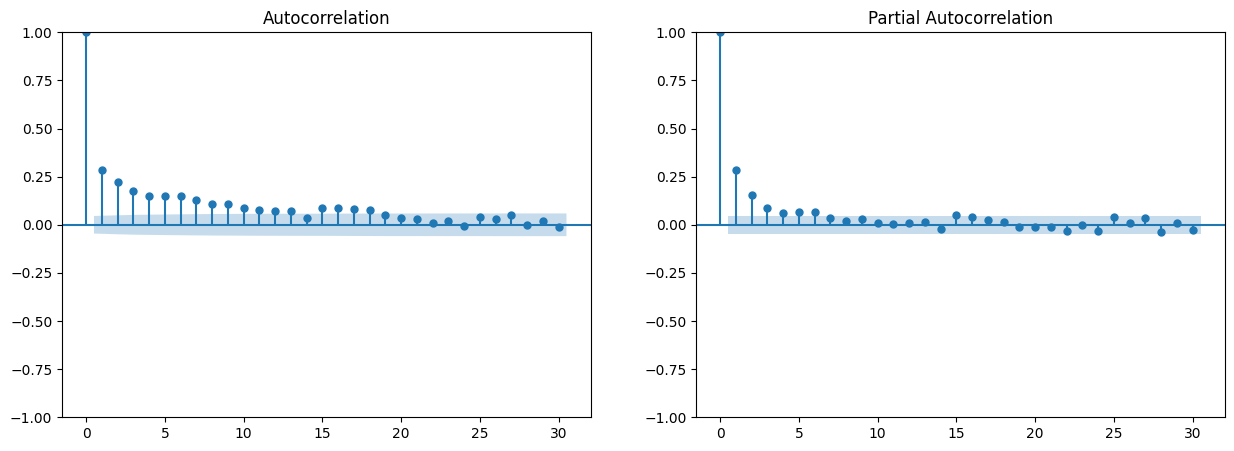

Frankfurt_1


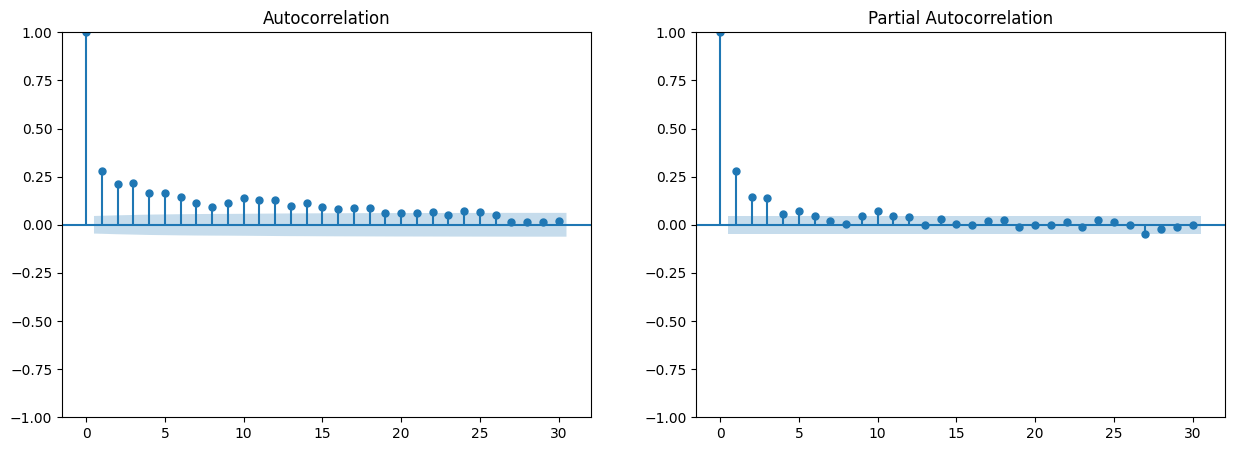

Budapest_1


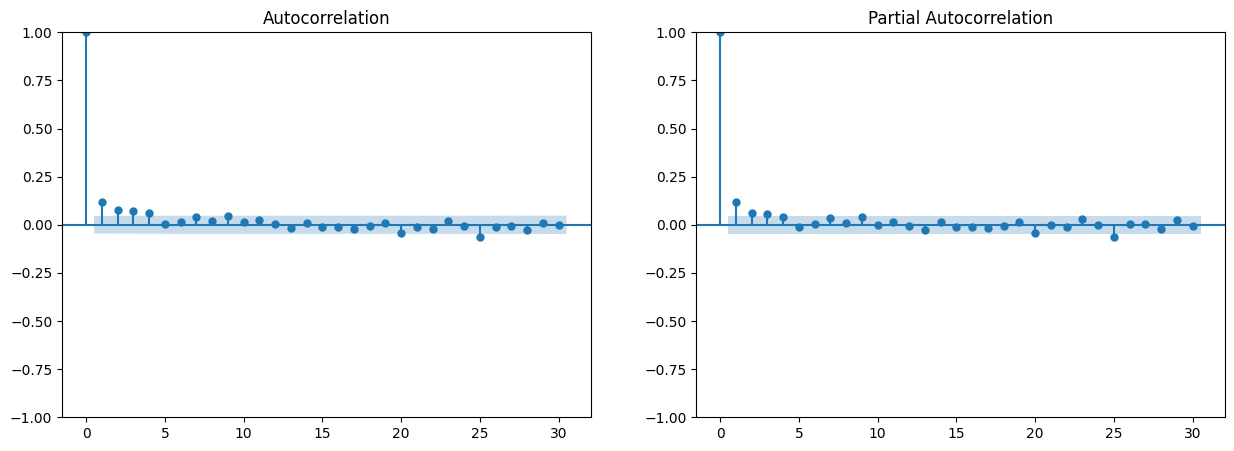

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

for warehouse in df['warehouse'].unique():
  print(f"{warehouse}")
  w_orders = df_train[df_train['warehouse'] == warehouse]['orders']

  fig, ax = plt.subplots(1, 2, figsize=(15, 5))
  plot_acf(w_orders, lags=30, ax=ax[0])
  plot_pacf(w_orders, lags=30, ax=ax[1])
  plt.show()